In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from pylr2 import regress2

warnings.filterwarnings('ignore', message="Could not infer format")

Configuration:

Defining configuration parameters and file paths for the rainfall analysis project. This includes the file paths for the CORMP, Davis, and OWLR datasets, as well as the start and end timestamps for the analysis period.


In [2]:
FILES = {
    "TR525": "Data/precip_CORMP_04132026.csv",
    "Aerocone": "Data/precip_Davis_04132026.csv",
    "OWLR":  "Data/OWLR_CMS_04132026.csv"
}

START = pd.to_datetime("2025-12-19 09:00")
END   = pd.to_datetime("2026-04-13 08:00")

Analysis wide variables:

Creating reusable functions to clean, align, and process rainfall data across sensors.

In [3]:
def keep_period(df):
    return df[(df["datetime"].between(START, END))].reset_index(drop=True)

def finalize(df, col_name, resample=True):
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")
    df = df[["datetime", col_name]].dropna()
    
    if resample:
        df = df.set_index("datetime").resample("h", closed="right", label="right").sum().reset_index()
#!!!
# when summing for pandas bins  are left-closed, right-open: [11:00, 12:00) and labeled by the left edge sp this code changes it to the other way.

    return keep_period(df)

Sensor-specific changes:

Cleaning and combining rainfall data from different sensors so they all match the same format.

In [4]:
def load_cormp(fp):
    df = pd.read_csv(fp, skiprows=7, usecols=[0, 1])
    df.columns = ["datetime", "rain_mm_tr525"]
    df["rain_mm_tr525"] *= 25.4
    return finalize(df, "rain_mm_tr525")


def load_davis(fp):
    df = pd.read_csv(fp, skiprows=6, names=["datetime", "rain_mm_aerocone"])
    return finalize(df, "rain_mm_aerocone")


def load_owlr(fp):
    df = pd.read_csv(fp, header=None,
                     names=["device_id", "datetime", "blank", "event", "payload"])
    df["rain_mm_owlr"] = df["payload"].str.split(",").str[2]
    return finalize(df, "rain_mm_owlr", resample=False)

def prepare(df, name):
    df["datetime"] = df["datetime"].dt.floor("h")
    return df.rename(columns={"rain_mm_owlr": name})


Loads raw rainfall data from each sensor, standardizes it, and merges everything into one combined dataset for comparison in future analyses. 

In [5]:
print("Loading and processing rainfall data...")

TR525 = prepare(load_cormp(FILES["TR525"]), "rain_mm_tr525")
Aerocone = prepare(load_davis(FILES["Aerocone"]), "rain_mm_aerocone")
OWLR  = prepare(load_owlr(FILES["OWLR"]),  "rain_mm_owlr")

rainfall_all = (
    TR525.merge(Aerocone, on="datetime", how="outer")
          .merge(OWLR, on="datetime", how="outer")
)

print(f"  TR-525l: {len(TR525)} hourly records")
print(f"  Aerocone: {len(Aerocone)} hourly records")
print(f"  OWLR: {len(OWLR)} hourly records")
print(f"  Zero rainfall points (OWLR): {np.sum(OWLR['rain_mm_owlr'] == 0)}") #checking zero amounts
print(f"  Combined comparison table: {rainfall_all.shape}")



Loading and processing rainfall data...
  TR-525l: 2760 hourly records
  Aerocone: 2760 hourly records
  OWLR: 2753 hourly records
  Zero rainfall points (OWLR): 2678
  Combined comparison table: (2765, 4)


In [6]:
TR525.iloc[360:380]

,datetime,rain_mm_tr525
360,2026-01-03 09:00:00,0.000
361,2026-01-03 10:00:00,0.000
362,2026-01-03 11:00:00,0.000
363,2026-01-03 12:00:00,0.000
364,2026-01-03 13:00:00,0.000
365,2026-01-03 14:00:00,0.000
366,2026-01-03 15:00:00,0.000
367,2026-01-03 16:00:00,0.000
368,2026-01-03 17:00:00,1.016
369,2026-01-03 18:00:00,2.032


In [7]:
Aerocone.iloc[360:380]

,datetime,rain_mm_aerocone
360,2026-01-03 09:00:00,0.0
361,2026-01-03 10:00:00,0.0
362,2026-01-03 11:00:00,0.0
363,2026-01-03 12:00:00,1.0
364,2026-01-03 13:00:00,2.1
365,2026-01-03 14:00:00,1.1
366,2026-01-03 15:00:00,0.0
367,2026-01-03 16:00:00,1.1
368,2026-01-03 17:00:00,0.8
369,2026-01-03 18:00:00,0.6


In [8]:
OWLR.iloc[360:380]

,datetime,rain_mm_owlr
360,2026-01-03 08:00:00,0.00
361,2026-01-03 09:00:00,0.00
362,2026-01-03 10:00:00,0.00
363,2026-01-03 11:00:00,0.00
364,2026-01-03 12:00:00,0.56
365,2026-01-03 13:00:00,1.68
366,2026-01-03 14:00:00,0.28
367,2026-01-03 15:00:00,0.00
368,2026-01-03 16:00:00,0.84
369,2026-01-03 17:00:00,0.56


In [9]:
rainfall_all.iloc[360:380]

,datetime,rain_mm_tr525,rain_mm_aerocone,rain_mm_owlr
360,2026-01-03 08:00:00,0.000,0.0,0.00
361,2026-01-03 09:00:00,0.000,0.0,0.00
362,2026-01-03 10:00:00,0.000,0.0,0.00
363,2026-01-03 11:00:00,0.000,0.0,0.00
364,2026-01-03 12:00:00,0.000,1.0,0.56
365,2026-01-03 13:00:00,0.000,2.1,1.68
366,2026-01-03 14:00:00,0.000,1.1,0.28
367,2026-01-03 15:00:00,0.000,0.0,0.00
368,2026-01-03 16:00:00,0.000,1.1,0.84
369,2026-01-03 17:00:00,1.016,0.8,0.56


Global names and colors

In [10]:
SENSORS = {
    "TR525": {
        "col": "rain_mm_tr525",
        "label": "TR525l",
        "color": "crimson",
        "marker": "s",
        "is_ref": True
    },
    "Aerocone": {
        "col": "rain_mm_aerocone",
        "label": "Aerocone",
        "color": "steelblue",
        "marker": "o",
        "is_ref": False
    },
    "OWLR": {
        "col": "rain_mm_owlr",
        "label": "OWLR",
        "color": "darkgreen",
        "marker": "^",
        "is_ref": False
    }
}

Finished data sets: 
Extracts a specific time dataset from all sensors, standardizes column names, and ends up optionally applying OWLR calibration which I will use in event specific analyses. 

In [11]:
def filter_window(df, start, end):
    df['datetime'] = pd.to_datetime(df['datetime'])
    return df[(df['datetime'] >= start) & (df['datetime'] <= end)]

def build_event_frame(start, end, calibrate_owlr=False, m=None, b=None):
    df = filter_window(rainfall_all, start, end).copy()

    df = df.rename(columns={
        "tr525_mm":    "rain_mm_tr525",
        "aerocone_mm": "rain_mm_aerocone",
        "owlr_mm":     "rain_mm_owlr"
    })

    if calibrate_owlr:
        if m is None or b is None:
            raise ValueError("Provide calibration coefficients m and b.")
        df["rain_mm_owlr_cal"] = (m * df["rain_mm_owlr"] + b).clip(lower=0)

    return df



Global r-squared: Compares two sensors by matching their data points and calculating how strongly they agree

In [12]:
def paired_metrics(df, x, y):
    pair = df[[x, y]].dropna()
    if len(pair) < 2:
        return pair, np.nan, np.nan
    r = pair[x].corr(pair[y])
    return pair, r, r**2

# Step 1:Type 1 Linear Regression of TR525 vs. OWLR and Aerocone


In [13]:

XCOL = 'rain_mm_tr525'

def stats_pair(x, y):
    pair = pd.concat([x, y], axis=1).dropna()

    if len(pair) < 2:
        return pair, np.nan, np.nan, np.nan, np.nan, np.nan

    x_clean = pair.iloc[:, 0]
    y_clean = pair.iloc[:, 1]

    r = x_clean.corr(y_clean)
    r2 = r ** 2 if pd.notna(r) else np.nan
    slope, intercept = np.polyfit(x_clean, y_clean, 1)

    # MAPE
    mask = y_clean != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_clean[mask] - x_clean[mask]) / y_clean[mask])) * 100
    else:
        mape = np.nan

    return pair, r, r2, slope, intercept, mape

results = {}

for sensor_name, cfg in SENSORS.items():
    if cfg.get('is_ref', False):
        continue

    col = cfg['col']
    results[sensor_name] = stats_pair(rainfall_all[XCOL], rainfall_all[col])

    pair, r, r2, slope, intercept, mape = results[sensor_name]

    print()
    print("TR525 vs", sensor_name)
    print("  Paired points:", len(pair))
    print("  R²:", round(r2, 4) if pd.notna(r2) else np.nan)
    print("  Slope:", round(slope, 4) if pd.notna(slope) else np.nan)
    print("  Intercept:", round(intercept, 4) if pd.notna(intercept) else np.nan)
    print("  MAPE (%):", round(mape, 2) if pd.notna(mape) else np.nan)




TR525 vs Aerocone
  Paired rainfall events: 32
  R²: 0.0103
  Slope: -0.1204
  Intercept: 2.8514
  MAPE (%): 435.85

TR525 vs OWLR
  Paired rainfall events: 20
  R²: 0.0
  Slope: -0.0008
  Intercept: 2.2242
  MAPE (%): 201.64


Plotting the Type 1 Linear Regression

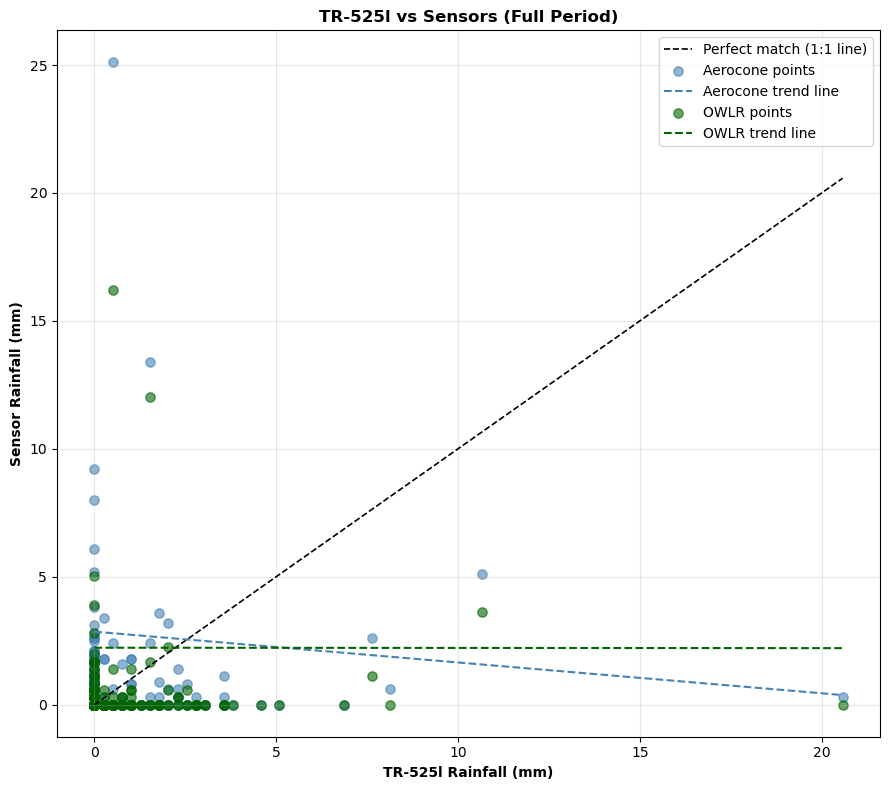

In [14]:
plt.figure(figsize=(9, 8))

# Get TR-525l data 
tr525 = rainfall_all[XCOL].dropna()
x_min = tr525.min()
x_max = tr525.max()

# Draw the perfect fit line
plt.plot(
    [x_min, x_max],
    [x_min, x_max],
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Perfect match (1:1 line)'
)

# Loop through aero and owlr
for sensor_name, cfg in SENSORS.items():
    if cfg.get('is_ref', False):
        continue

    column = cfg['col']
    color = cfg['color']
    label = cfg['label']

    clean_data = rainfall_all[[XCOL, column]].dropna()
    x_values = clean_data[XCOL]
    y_values = clean_data[column]

    plt.scatter(
        x_values,
        y_values,
        s=45,
        alpha=0.6,
        color=color,
        label=f'{label} points'
    )

    pair, r, r2, slope, intercept, mape = results[sensor_name]
    if pd.notna(slope) and pd.notna(intercept):
        x_line = np.linspace(x_min, x_max, 100)
        y_line = slope * x_line + intercept
        plt.plot(
            x_line,
            y_line,
            '--',
            color=color,
            label=f'{label} trend line'
        )
plt.xlabel('TR-525l Rainfall (mm)', fontweight='bold')
plt.ylabel('Sensor Rainfall (mm)', fontweight='bold')
plt.title('TR-525l vs Sensors (Full Period)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Step 2: Type 2 Regression + Residuals Plots
TR525 vs. Aerocone and OWLR
Assumes that all sensors have error

This step makes sure that for each timestamp there is corresponding data from Tr525 vs. OWLR and TR525 vs. Aerocone so the regression works.

In [15]:
paired = rainfall_all[['datetime', 'rain_mm_tr525', 'rain_mm_owlr']].dropna()
paired_aero = rainfall_all[['datetime', 'rain_mm_tr525', 'rain_mm_aerocone']].dropna()

# Validate there is enough data ( this may be repetitive also)
if len(paired) < 2 or len(paired_aero) < 2:
    raise ValueError('Not enough overlapping hourly points for Type II regression.')

# Extract variables for regression
x = paired['rain_mm_tr525'].to_numpy()
y = paired['rain_mm_owlr'].to_numpy()
x_aero = paired_aero['rain_mm_tr525'].to_numpy()
y_aero = paired_aero['rain_mm_aerocone'].to_numpy()

In [16]:

fit = regress2(x, y, _method_type_2='reduced major axis')
slope = fit.get('slope', np.nan)
intercept = fit.get('intercept', np.nan)
r = fit.get('r', np.corrcoef(x, y)[0, 1])
r2 = r**2 if np.isfinite(r) else np.nan

fit_aero = regress2(x_aero, y_aero, _method_type_2='reduced major axis')
slope_aero = fit_aero.get('slope', np.nan)
intercept_aero = fit_aero.get('intercept', np.nan)
r_aero = fit_aero.get('r', np.corrcoef(x_aero, y_aero)[0, 1])
r2_aero = r_aero**2 if np.isfinite(r_aero) else np.nan

# Calculate residuals and performance metrics
y_hat = slope * x + intercept
residuals = y - y_hat
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))
resid_mean = np.mean(residuals)
resid_std = np.std(residuals, ddof=1)

# MAPE
nonzero_mask = y != 0

mape = np.mean(
    np.abs((y[nonzero_mask] - y_hat[nonzero_mask]) / y[nonzero_mask])
) * 100

# Print regression results
print(f'Overlapping hourly points: OWLR={len(paired)}, Aerocone={len(paired_aero)}')
print(f'\nType II RMA regression equations:')
print(f'  OWLR = {slope:.4f} × TR-525l + {intercept:.4f}')
print(f'  Aerocone = {slope_aero:.4f} × TR-525l + {intercept_aero:.4f}')
print(f'\nRegression fit statistics:')
print(f'  OWLR: r = {r:.4f}, r² = {r2:.4f}')
print(f'  Aerocone: r = {r_aero:.4f}, r² = {r2_aero:.4f}')
print(f'\nOWLR residual statistics (mm):')
print(f'  Mean: {resid_mean:.4f} | Std Dev: {resid_std:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}')
print(f'  MAPE: {mape:.2f}%')

print("Total points:", len(residuals))
print("Zero rainfall points (TR525):", np.sum(x == 0))
print("Zero rainfall points (OWLR):", np.sum(y == 0))
print("Zero residuals:", np.sum(np.isclose(residuals, 0)))



Overlapping hourly points: OWLR=2753, Aerocone=2765

Type II RMA regression equations:
  OWLR = 0.7343 × TR-525l + -0.0135
  Aerocone = 1.1368 × TR-525l + -0.0049

Regression fit statistics:
  OWLR: r = 0.1189, r² = 0.0141
  Aerocone: r = 0.1382, r² = 0.0191

OWLR residual statistics (mm):
  Mean: -0.0000 | Std Dev: 0.5748 | MAE: 0.0806 | RMSE: 0.5747
  MAPE: 113.39%
Total points: 2753
Zero rainfall points (TR525): 2649
Zero rainfall points (OWLR): 2678
Zero residuals: 0


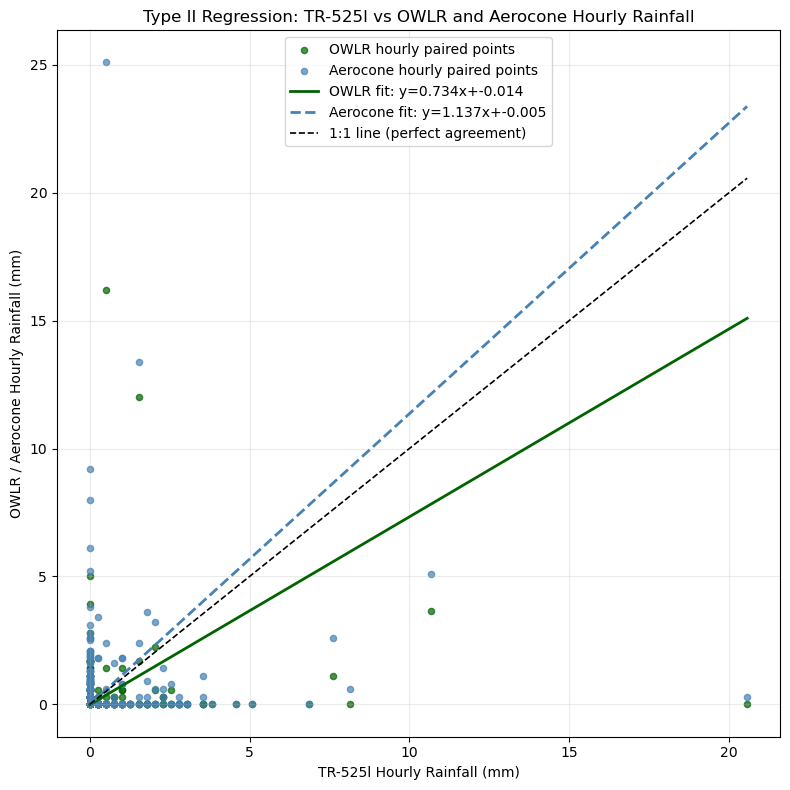

In [17]:
plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=20, alpha=0.7, label='OWLR hourly paired points', color='darkgreen')
plt.scatter(x_aero, y_aero, s=20, alpha=0.7, label='Aerocone hourly paired points', color='steelblue')

xmin = min(np.nanmin(x), np.nanmin(x_aero))
xmax = max(np.nanmax(x), np.nanmax(x_aero))
xline = np.linspace(xmin, xmax, 200)
plt.plot(xline, slope * xline + intercept, color='darkgreen', lw=2,
         label=f'OWLR fit: y={slope:.3f}x+{intercept:.3f}')
plt.plot(xline, slope_aero * xline + intercept_aero, color='steelblue', lw=2, ls='--',
         label=f'Aerocone fit: y={slope_aero:.3f}x+{intercept_aero:.3f}')
plt.plot(xline, xline, color='black', ls='--', lw=1.2, label='1:1 line (perfect agreement)')

plt.xlabel('TR-525l Hourly Rainfall (mm)')
plt.ylabel('OWLR / Aerocone Hourly Rainfall (mm)')
plt.title('Type II Regression: TR-525l vs OWLR and Aerocone Hourly Rainfall')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


Plot Residuals vs predicted values (for OWLR comparison)


-9.678660585181169e-19


-9.678660585181169e-19


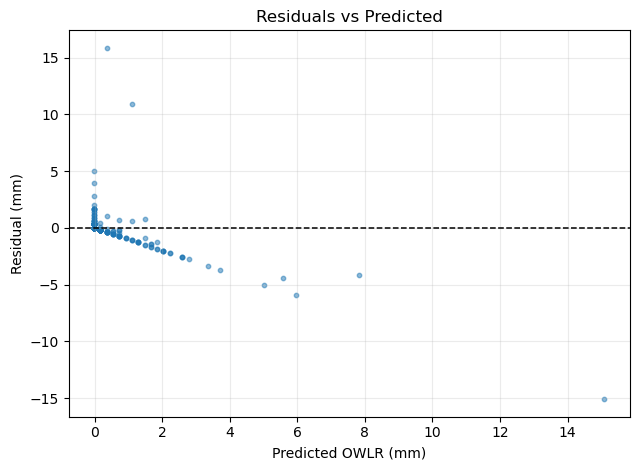

In [18]:
plt.figure(figsize=(6.5, 4.8))
plt.scatter(y_hat, residuals, s=10, alpha=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1.1)
plt.xlabel('Predicted OWLR (mm)')
plt.ylabel('Residual (mm)')
plt.title('Residuals vs Predicted')
print(np.mean(residuals))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Same residuals vs. predicted plot BUT put a mask to only show values during a rain event. 

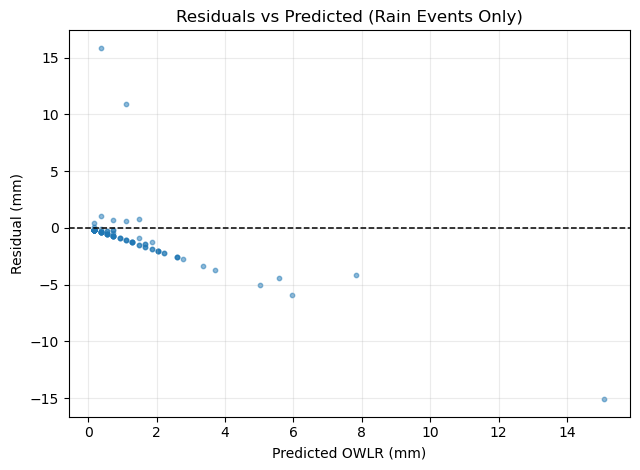

In [19]:
rain_mask = x > 0.1 # .28 is OWLR resolution but made it a little lower.

plt.figure(figsize=(6.5, 4.8))
plt.scatter(y_hat[rain_mask], residuals[rain_mask], s=10, alpha=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1.1)

plt.xlabel('Predicted OWLR (mm)')
plt.ylabel('Residual (mm)')
plt.title('Residuals vs Predicted (Rain Events Only)')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Residual distribution (for OWLR comparison)

Uses values only above .1 so it doesn't include all the 0s.

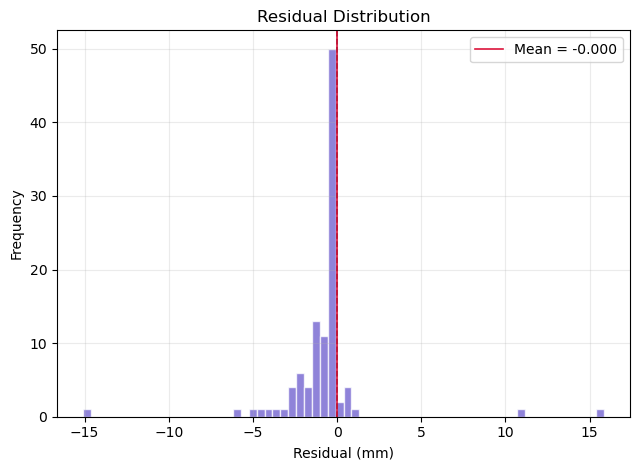

In [20]:

rain_mask = x > 0.1   # .28 is OWLR resolution but made it a little lower. 
residuals_rain = residuals[rain_mask]
y_hat_rain = y_hat[rain_mask]

plt.figure(figsize=(6.5, 4.8))
plt.hist(residuals_rain, bins='auto', color='slateblue', alpha=0.75, edgecolor='white')
plt.axvline(0, color='black', linestyle='--', linewidth=1.1)
plt.axvline(resid_mean, color='crimson', linestyle='-', linewidth=1.2, label=f'Mean = {resid_mean:.3f}')
plt.xlabel('Residual (mm)')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Step 3: Post-Calibration of OWLR

Uses the TR525 to determine m and b values but then determines via this equation:
 owl_calibrated = m * owl_raw + b 

Preparing to compare all sensors to a reference sensor during a specific time.

In [21]:
df = build_event_frame(START, END).copy()

# build paired dataset 
def get_pair(df, col):
    return df[['rain_mm_tr525', col]].dropna()

owlr_df = get_pair(df, 'rain_mm_owlr')
aero_df = get_pair(df, 'rain_mm_aerocone')

A calibration and performance eval of the OWLR sensor against TR-525l, with a comparison to Aerocone.

In [22]:
if len(owlr_df) < 2:
    print("Not enough OWLR points for calibration regression.")

else:
    #  Calibration using TR-525
    from scipy import stats
    
    owlr_raw = owlr_df['rain_mm_owlr']
    tr525 = owlr_df['rain_mm_tr525']   # reference sensor

    m, b, r, *_ = stats.linregress(owlr_raw, tr525)

    owlr_df['owlr_cal'] = m * owlr_raw + b

    def metrics(obs, ref):
        r = ref.corr(obs)
        r2 = r**2 if pd.notna(r) else np.nan
        rmse = np.sqrt(np.mean((obs - ref) ** 2))
        return r2, rmse

    r2_raw, rmse_raw = metrics(owlr_raw, tr525)
    r2_cal, rmse_cal = metrics(owlr_df['owlr_cal'], tr525)

    print(f"Calibration: OWLR_cal = {m:.4f} * OWLR_raw + {b:.4f}")
    print(f"R² raw: {r2_raw:.4f} | RMSE raw: {rmse_raw:.4f}")
    print(f"R² cal: {r2_cal:.4f} | RMSE cal: {rmse_cal:.4f}")

    # Include aerocone and metrics
    if len(aero_df) >= 2:
        r2_aero, rmse_aero = metrics(
            aero_df['rain_mm_aerocone'],
            aero_df['rain_mm_tr525']
        )
        print(f"R² Aerocone: {r2_aero:.4f} | RMSE: {rmse_aero:.4f}")

Calibration: OWLR_cal = 0.1619 * OWLR_raw + 0.0573
R² raw: 0.0141 | RMSE raw: 0.6894
R² cal: 0.0141 | RMSE cal: 0.5854
R² Aerocone: 0.0191 | RMSE: 0.8278


Plot TR525 vs. calibrated OWLR and Aerocone

I fit a line predicting TR-525 from OWLR, but now I’m plotting OWLR vs TR-525—so I flipped the equation to match the axes

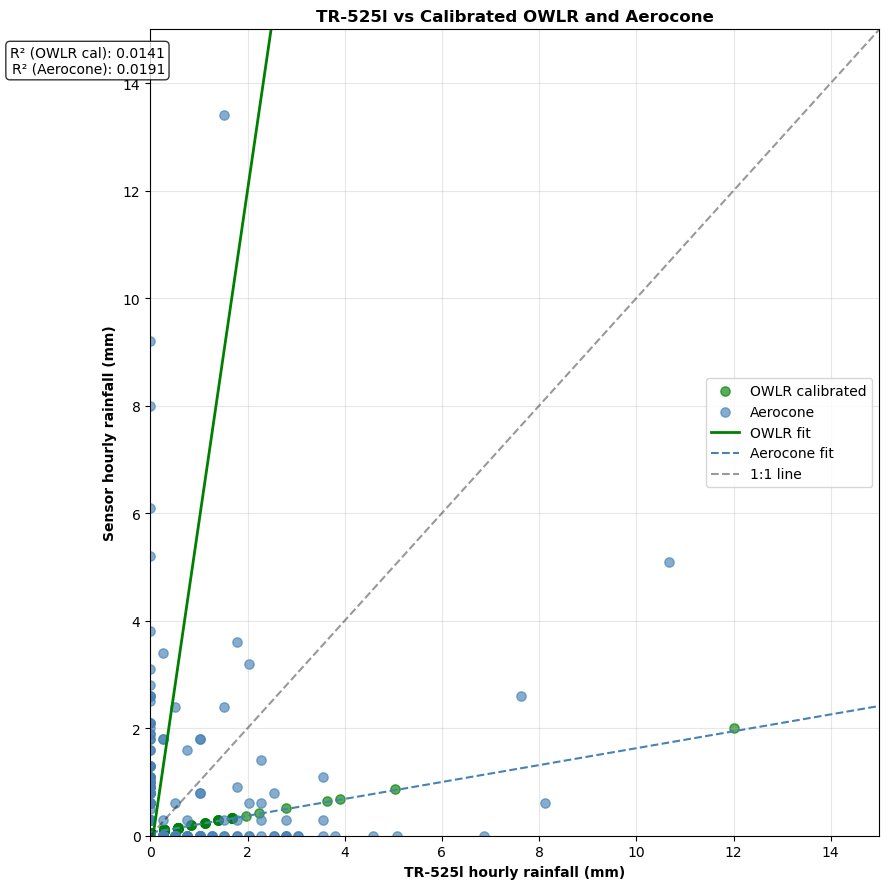

In [23]:

    plt.figure(figsize=(9, 9))

    plt.scatter(y, owlr_df['owlr_cal'], s=45, alpha=0.65, color='green', label='OWLR calibrated')

    if not aero_df.empty:
        plt.scatter(aero_df['rain_mm_tr525'], aero_df['rain_mm_aerocone'],
                    s=45, alpha=0.65, color='steelblue', label='Aerocone')

    x_line = np.linspace(y.min(), y.max(), 200)

    if not np.isclose(m, 0):
        plt.plot(x_line, (x_line - b) / m, color='green', lw=2, label='OWLR fit')

    if len(aero_df) >= 2:
        from scipy import stats
        m_a, b_a, *_ = stats.linregress(aero_df['rain_mm_tr525'], aero_df['rain_mm_aerocone'])
        plt.plot(x_line, m_a * x_line + b_a, '--', color='steelblue', label='Aerocone fit')

    max_value = 15

    plt.plot([0, max_value], [0, max_value], 
         color='black', linestyle='--', alpha=0.4, label='1:1 line')

    plt.xlim(0, max_value)
    plt.ylim(0, max_value)

    # Labels
    plt.xlabel('TR-525l hourly rainfall (mm)', fontweight='bold')
    plt.ylabel('Sensor hourly rainfall (mm)', fontweight='bold')
    plt.title('TR-525l vs Calibrated OWLR and Aerocone', fontweight='bold')

    text = [f'R² (OWLR cal): {r2_cal:.4f}']
    if pd.notna(r2_aero):
        text.append(f'R² (Aerocone): {r2_aero:.4f}')

    plt.gca().text(
        0.02, 0.98, '\n'.join(text),
        transform=plt.gca().transAxes,
        va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Step 4: 2D Histogram for TR525 vs. Calibrated OWLR data

Change to owlr raw?

In [24]:
from matplotlib.colors import LogNorm

# Calibrated data from above.
x_hist = owlr_df['rain_mm_tr525'].to_numpy()
y_hist = owlr_df['owlr_cal'].to_numpy()

valid = np.isfinite(x_hist) & np.isfinite(y_hist)
x_hist = x_hist[valid]
y_hist = y_hist[valid]

if len(x_hist) < 2:
    raise ValueError("Not enough valid data for 2D histogram.")

# Center around mean
x_anom = x_hist - np.mean(x_hist)
y_anom = y_hist - np.mean(y_hist)

# bin size
bin_size = 0.25
lim = np.percentile(np.abs(np.concatenate([x_anom, y_anom])), 99)

edges = np.arange(-lim, lim + bin_size, bin_size)

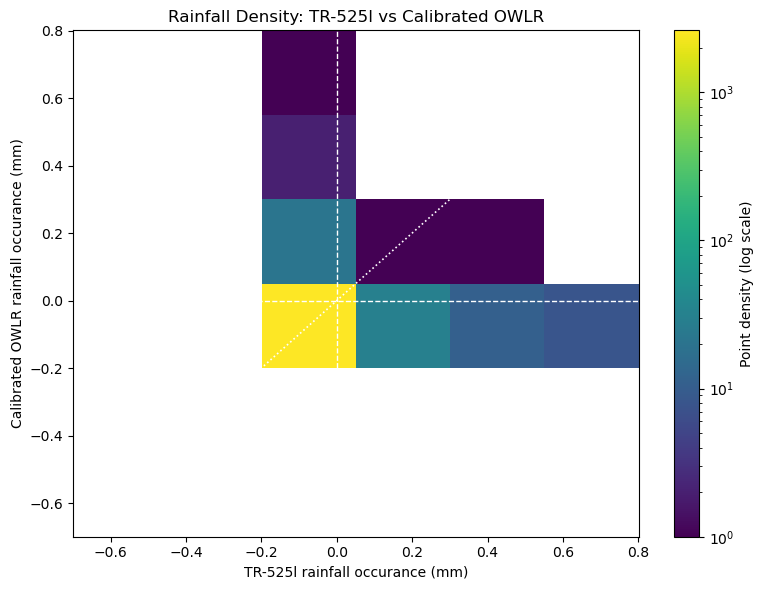

In [25]:

fig, ax = plt.subplots(figsize=(8, 6))

# 2D histogram (density view)
hist = ax.hist2d(
    x_anom,
    y_anom,
    bins=[edges, edges],
    cmap='viridis',
    norm=LogNorm(vmin=1)
)

cbar = plt.colorbar(hist[3], ax=ax)
cbar.set_label("Point density (log scale)")

ax.axhline(0, color='white', linestyle='--', linewidth=1)
ax.axvline(0, color='white', linestyle='--', linewidth=1)
ax.plot([-lim, lim], [-lim, lim], 'w:', linewidth=1.2, label="1:1 line")

ax.set_xlabel("TR-525l rainfall occurance (mm)")
ax.set_ylabel("Calibrated OWLR rainfall occurance (mm)")
ax.set_title("Rainfall Density: TR-525l vs Calibrated OWLR")

plt.tight_layout()
plt.show()

# Scatter Plot for TR525, Aerocone, and OWLR Calibrated data for Time Period

TR-525l points plotted: 2765
Aerocone points plotted: 2765
OWLR calibrated points plotted: 2753


TR-525l points plotted: 2765
Aerocone points plotted: 2765
OWLR calibrated points plotted: 2753


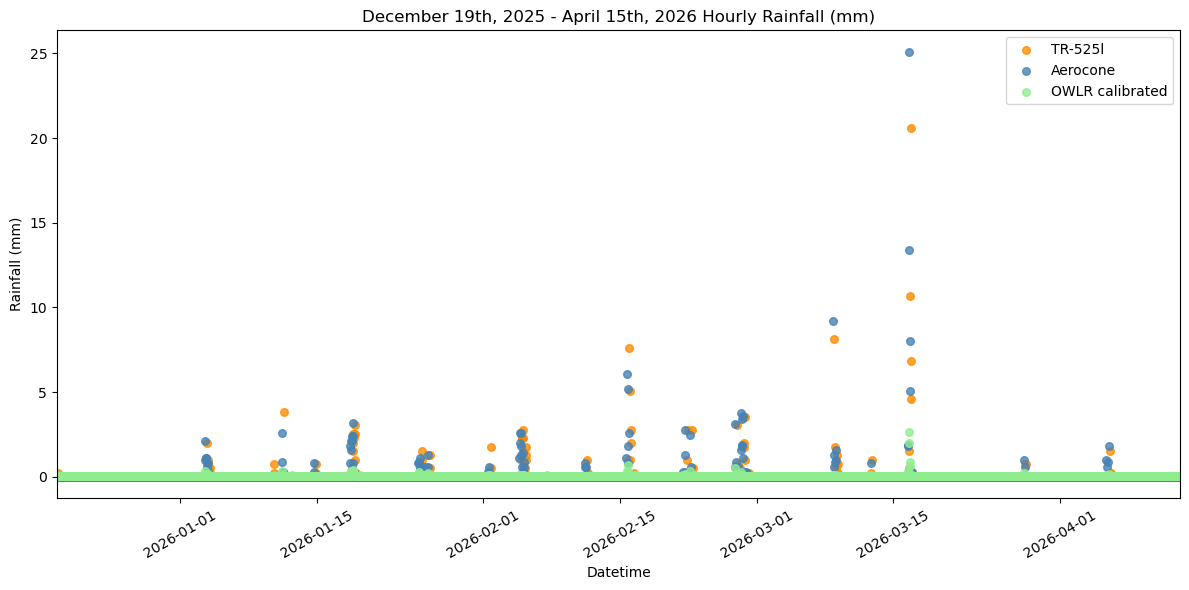

In [26]:
coeff_m = globals().get('m')
coeff_b = globals().get('b')
if coeff_m is None or coeff_b is None:
    raise ValueError('Run the calibration cell first to compute calibration coefficients m and b.')

# dataframe
plot_df = rainfall_all.copy()
plot_df['rain_mm_owlr_cal'] = (coeff_m * plot_df['rain_mm_owlr'] + coeff_b).clip(lower=0)

#Count points again to make sure
tr525_points = plot_df['rain_mm_tr525'].notna().sum()
aerocone_points = plot_df['rain_mm_aerocone'].notna().sum()
owlr_points = plot_df['rain_mm_owlr_cal'].notna().sum()

print(f'TR-525l points plotted: {tr525_points}')
print(f'Aerocone points plotted: {aerocone_points}')
print(f'OWLR calibrated points plotted: {owlr_points}')

plt.figure(figsize=(12, 6))
if not plot_df['rain_mm_tr525'].isna().all():
    plt.scatter(plot_df['datetime'], plot_df['rain_mm_tr525'], label='TR-525l', s=30, alpha=0.8, color='darkorange')
if not plot_df['rain_mm_aerocone'].isna().all():
    plt.scatter(plot_df['datetime'], plot_df['rain_mm_aerocone'], label='Aerocone', s=30, alpha=0.8, color='steelblue')
if not plot_df['rain_mm_owlr_cal'].isna().all():
    plt.scatter(plot_df['datetime'], plot_df['rain_mm_owlr_cal'], label='OWLR calibrated', s=30, alpha=0.8, color='lightgreen')

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('December 19th, 2025 - April 15th, 2026 Hourly Rainfall (mm)')
plt.legend()
plt.xlim(START, END)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Non-Zero Rainfall Events Linear Regression

Calculations for linear regression once all zero values are excluded for all sensors

In [60]:
plot_pairs = [
    ("Aerocone", "rain_mm_aerocone", "steelblue"),
    ("OWLR", "rain_mm_owlr", "forestgreen"),
]

results = []
summary_lines = []
all_values = []

for sensor_label, sensor_col, color in plot_pairs:
    pair = rainfall_all[[XCOL, sensor_col]].dropna()
    pair = pair[(pair[XCOL] > 0) & (pair[sensor_col] > 0)]

    if len(pair) < 2:
        summary_lines.append(f"{sensor_label}: not enough data")
        continue

    x = pair[XCOL]
    y = pair[sensor_col]

    # regression
    slope, intercept, r, _, _ = stats.linregress(x, y)
    r2 = r**2

    # line for plotting later
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    # store everything needed for plotting
    results.append({
        "label": sensor_label,
        "color": color,
        "x": x,
        "y": y,
        "x_line": x_line,
        "y_line": y_line,
        "r2": r2,
        "slope": slope,
        "intercept": intercept,
    })

    all_values.append(max(x.max(), y.max()))
    summary_lines.append(
        f"{sensor_label}: n={len(pair)}, R²={r2:.3f}, "
        f"y = {slope:.4f}x + {intercept:.4f}"
    )


Plotting the non-zero linear regression

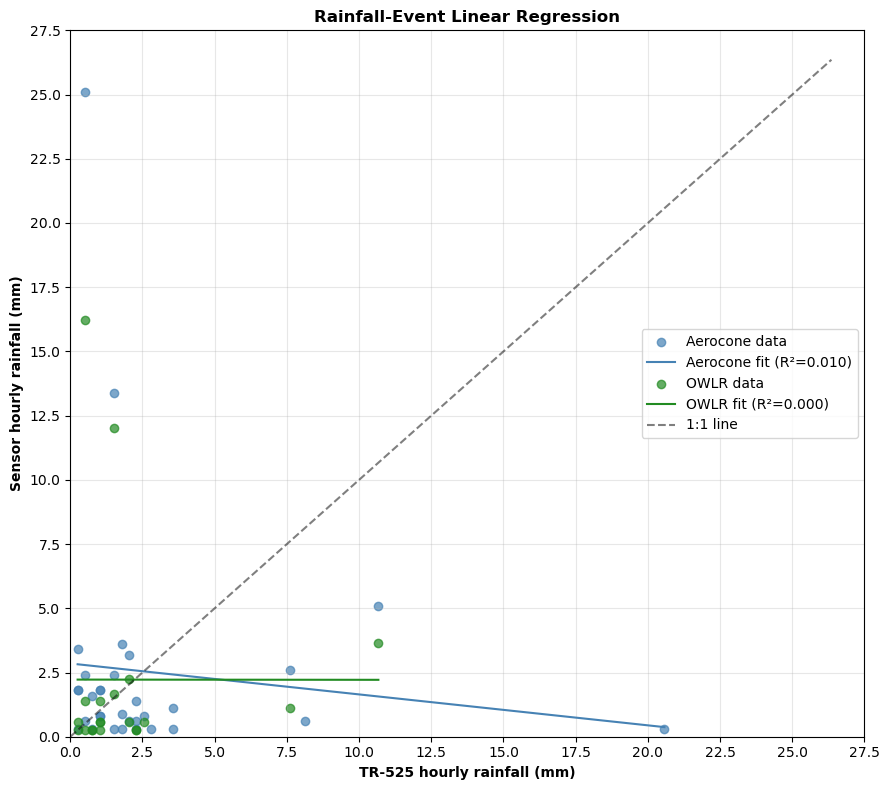

Aerocone: n=32, R²=0.010, y = -0.1204x + 2.8514
OWLR: n=20, R²=0.000, y = -0.0008x + 2.2242


In [61]:
plt.figure(figsize=(9, 8))

for res in results:
    plt.scatter(res["x"], res["y"],
                color=res["color"], alpha=0.7,
                label=f'{res["label"]} data')

    plt.plot(res["x_line"], res["y_line"],
             color=res["color"],
             label=f'{res["label"]} fit (R²={res["r2"]:.3f})')

# 1:1 line
limit = max(all_values) * 1.05 if all_values else 1
plt.plot([0, limit], [0, limit], 'k--', alpha=0.5, label="1:1 line")

plt.xlim(0, limit)
plt.ylim(0, limit)

ticks = np.arange(0, limit + 2.5, 2.5)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("TR-525 hourly rainfall (mm)", fontweight='bold')
plt.ylabel("Sensor hourly rainfall (mm)", fontweight='bold')
plt.title("Rainfall-Event Linear Regression", fontweight='bold')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# print summary
for line in summary_lines:
    print(line)

# Non-Zero/Zero Matrix

Computing counts and percantages for each portion on the matrix. 

In [43]:
sensors_cm = [
    ("Aerocone", "rain_mm_aerocone", "Blues"),
    ("OWLR",     "rain_mm_owlr",     "Greens"),
]

results = []

for label, col, cmap in sensors_cm:
    df = rainfall_all[[XCOL, col]].dropna()

    tr_zero = df[XCOL] == 0
    s_zero  = df[col] == 0

    counts = np.array([
        [(tr_zero & s_zero).sum(),   (tr_zero & ~s_zero).sum()],
        [(~tr_zero & s_zero).sum(),  (~tr_zero & ~s_zero).sum()]
    ])

    row_pct = counts / counts.sum(axis=1, keepdims=True) * 100

    results.append({
        "label": label,
        "cmap": cmap,
        "counts": counts,
        "row_pct": row_pct
    })

Plotting the matrix. 

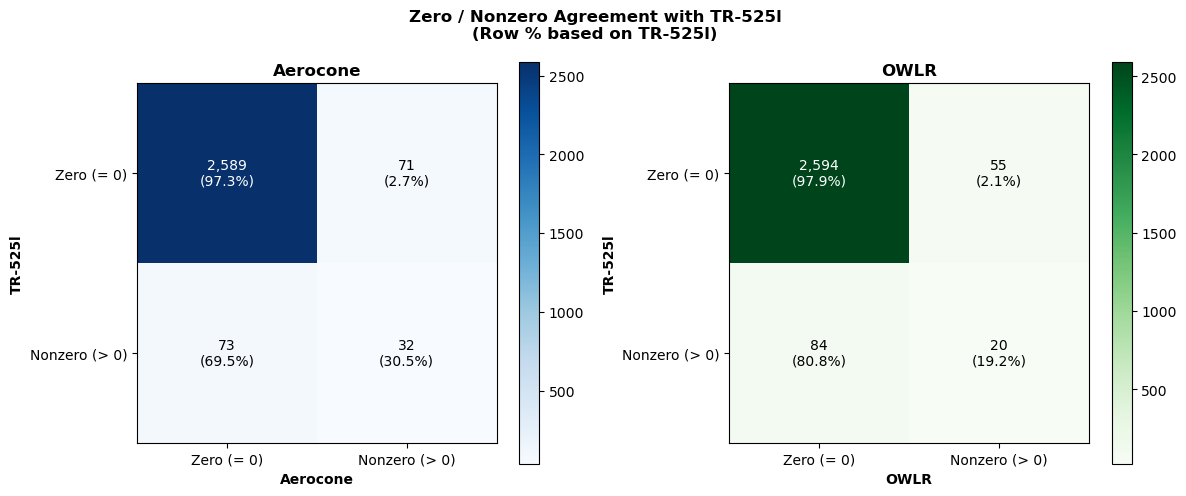

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res in zip(axes, results):
    counts = res["counts"]
    row_pct = res["row_pct"]

    im = ax.imshow(counts, cmap=res["cmap"])

    labels = ["Zero (= 0)", "Nonzero (> 0)"]
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)

    ax.set_xlabel(res["label"], fontweight='bold')
    ax.set_ylabel("TR-525l", fontweight='bold')
    ax.set_title(res["label"], fontweight='bold')

    for i in range(2):
        for j in range(2):
            val = counts[i, j]
            pct = row_pct[i, j]
            color = 'white' if val > counts.max() * 0.6 else 'black'

            ax.text(j, i, f"{val:,}\n({pct:.1f}%)",
                    ha='center', va='center', color=color)

    plt.colorbar(im, ax=ax)

fig.suptitle(
    "Zero / Nonzero Agreement with TR-525l\n(Row % based on TR-525l)",
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Linear Regression for rainfall events for Aerocone vs. OWLR

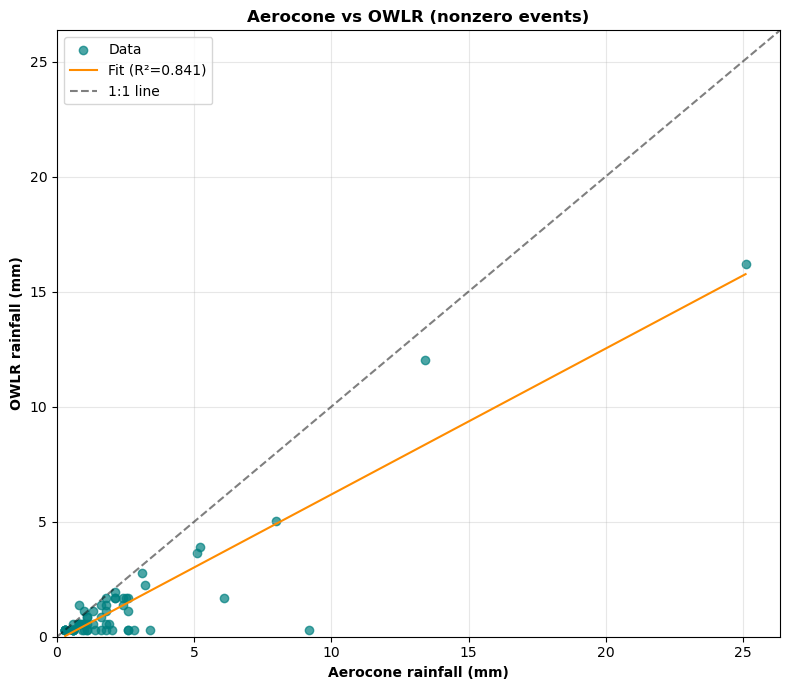

Aerocone vs OWLR: n=64, R²=0.841, y=0.634x + -0.158


In [67]:
aero_col = "rain_mm_aerocone"
owlr_col = "rain_mm_owlr"

df = rainfall_all[[aero_col, owlr_col]].dropna()
df = df[(df[aero_col] > 0) & (df[owlr_col] > 0)]

if len(df) < 2:
    print("Not enough data for regression.")
else:
    x = df[aero_col]
    y = df[owlr_col]

    # regression
    m, b, r, _, _ = stats.linregress(x, y)
    r2 = r**2

    # line
    x_line = np.linspace(x.min(), x.max(), 100)

    # limits
    lim = max(x.max(), y.max()) * 1.05

    # plot
    plt.figure(figsize=(8, 7))
    plt.scatter(x, y, color="teal", alpha=0.7, label="Data")
    plt.plot(x_line, m*x_line + b, color="darkorange",
             label=f"Fit (R²={r2:.3f})")
    plt.plot([0, lim], [0, lim], "k--", alpha=0.5, label="1:1 line")

    plt.xlim(0, lim)
    plt.ylim(0, lim)

    plt.xlabel("Aerocone rainfall (mm)", fontweight="bold")
    plt.ylabel("OWLR rainfall (mm)", fontweight="bold")
    plt.title("Aerocone vs OWLR (nonzero events)", fontweight="bold")

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Aerocone vs OWLR: n={len(df)}, R²={r2:.3f}, y={m:.3f}x + {b:.3f}")